In [1]:
import os
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.pipeline import Pipeline

In [2]:
TRAIN_CSV = "../data/alphabet/landmarks/train_landmarks_normalized.csv"
TEST_CSV = "../data/alphabet/landmarks/test_landmarks_normalized.csv"

train_df = pd.read_csv(TRAIN_CSV)
test_df = pd.read_csv(TEST_CSV)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

train_df.head()

Train shape: (4827, 66)
Test shape: (695, 66)


,x0,y0,z0,x1,y1,z1,x2,y2,z2,x3,...,z18,x19,y19,z19,x20,y20,z20,label,file_path,split
0,0.0,0.0,0.0,-0.285079,-0.005470,-0.132447,-0.536141,-0.280805,-0.154404,-0.610316,...,-0.198524,0.162542,-0.440788,-0.159892,0.153593,-0.346873,-0.091791,A,../data/alphabet/raw/train\A\Image_1685009115....,train
1,0.0,0.0,0.0,0.237101,-0.059265,-0.128390,0.451640,-0.331519,-0.153078,0.518450,...,-0.073203,-0.167767,-0.454129,-0.026119,-0.151433,-0.394190,0.035014,A,../data/alphabet/raw/train\A\Image_1685009117....,train
2,0.0,0.0,0.0,-0.067200,0.149242,-0.089536,-0.051379,0.373939,-0.221029,0.040574,...,-0.405370,0.247083,0.456774,-0.364406,0.249568,0.501492,-0.339672,A,../data/alphabet/raw/train\A\Image_1685009120....,train
3,0.0,0.0,0.0,0.252646,-0.143031,-0.062913,0.443554,-0.428070,-0.048246,0.485227,...,0.017269,-0.185673,-0.558414,0.028644,-0.144139,-0.443946,0.066502,A,../data/alphabet/raw/train\A\Image_1685009122....,train
4,0.0,0.0,0.0,-0.265195,-0.155066,-0.083215,-0.369033,-0.462475,-0.076585,-0.340364,...,0.032981,0.179019,-0.755773,0.022316,0.199794,-0.608524,0.053437,A,../data/alphabet/raw/train\A\Image_1685009125....,train


In [3]:
print(train_df["label"].value_counts())

label
A    390
G    350
H    311
Y    279
K    274
T    268
P    267
Q    259
N    230
E    229
L    200
I    198
D    186
F    185
S    170
O    141
C    140
U    139
B    131
X    127
M    112
V     88
R     79
W     74
Name: count, dtype: int64


In [8]:
X_train = train_df.drop(columns=["label", "file_path", "split"], errors="ignore")
y_train = train_df["label"]

X_test = test_df.drop(columns=["label", "file_path", "split"], errors="ignore")
y_test = test_df["label"]

In [9]:
label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

print("Classes:", list(label_encoder.classes_))

Classes: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y']


In [10]:
model = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPClassifier(
        hidden_layer_sizes=(128, 64),
        activation="relu",
        solver="adam",
        max_iter=500,
        random_state=42
    ))
])

In [11]:
model.fit(X_train, y_train_encoded)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('mlp', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(128, ...)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:re

In [12]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test_encoded, y_pred)
print(f"Test Accuracy: {accuracy:.4f}")

Test Accuracy: 0.7266


In [13]:
print(classification_report(
    y_test_encoded,
    y_pred,
    labels=range(len(label_encoder.classes_)),
    target_names=label_encoder.classes_,
    zero_division=0
))

              precision    recall  f1-score   support

           A       0.54      0.85      0.66        40
           B       0.85      0.85      0.85        20
           C       0.90      0.95      0.92        19
           D       0.67      0.67      0.67         9
           E       0.88      0.98      0.92        44
           F       0.94      0.76      0.84        42
           G       0.92      0.96      0.94        57
           H       0.76      0.71      0.74        55
           I       0.77      0.83      0.80        36
           K       0.90      0.83      0.86        23
           L       0.97      0.75      0.85        48
           M       0.09      0.07      0.08        14
           N       0.77      0.64      0.70        56
           O       0.50      0.62      0.55        13
           P       0.63      0.69      0.66        39
           Q       0.89      0.76      0.82        42
           R       0.00      0.00      0.00         6
           S       0.30    

In [14]:
all_classes = set(range(len(label_encoder.classes_)))
used_classes = set(y_test_encoded) | set(y_pred)
missing = all_classes - used_classes

print("Missing class indices:", missing)
print("Missing class names:", label_encoder.inverse_transform(list(missing)) if missing else [])

Missing class indices: set()
Missing class names: []


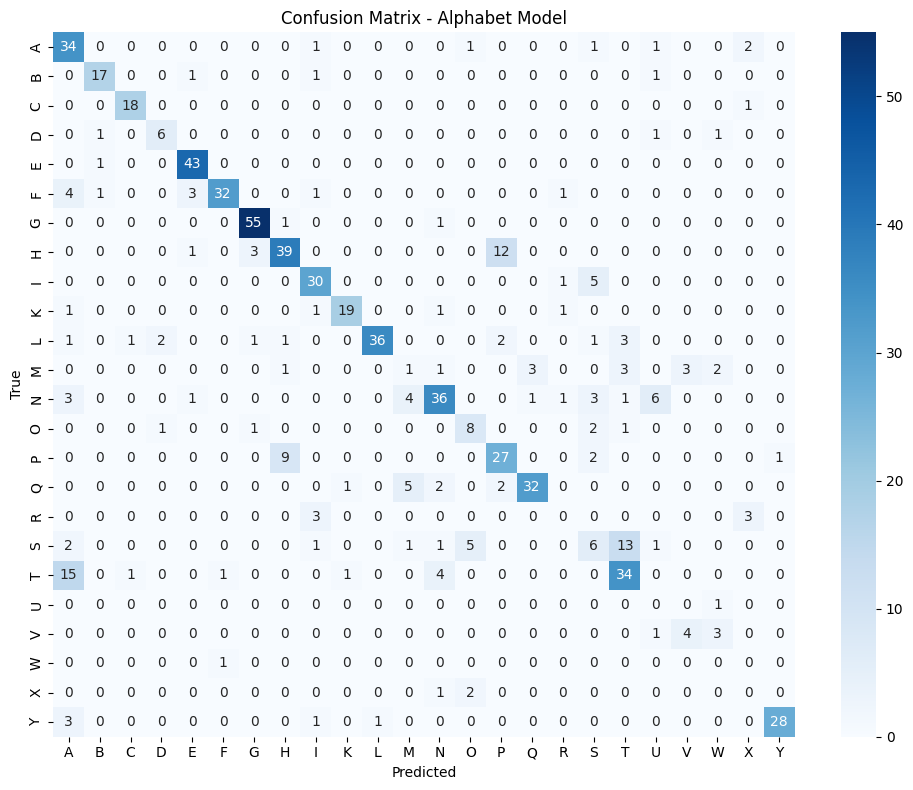

In [15]:
cm = confusion_matrix(y_test_encoded, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Alphabet Model")
plt.tight_layout()
plt.show()

In [16]:
os.makedirs("../models/alphabet", exist_ok=True)

joblib.dump(model, "../models/alphabet/alphabet_mlp_model.pkl")
joblib.dump(label_encoder, "../models/alphabet/alphabet_label_encoder.pkl")

print("Model and label encoder saved.")

Model and label encoder saved.
